### Monte Carlo demonstration

#### Hit-or-miss

Find the area of a quarter circle. 

$$A=\frac{\pi r^2}{4}\sim \frac{3.1415926535897932384626433}{4} = 0.7853981633974483.$$

Here, we set $r=1.$ 

The ratio of hitting rate will be the area of circle fan versus the area of square: 

$$\frac{\pi/4}{1}.$$

val = 0.787
pi/4 = 0.7853981633974483
relative error = 0.002039521706573115


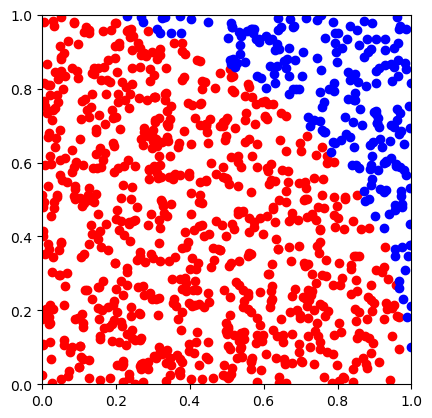

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

N = 1000

hit_x, hit_y = [], []  # optional: split for easy plotting
mis_x, mis_y = [], []  # optional: split for easy plotting

cnt = 0
# random numbers between 0 and 1
for i in range(N):
    x = random.uniform(0, 1)
    y = random.uniform(0, 1)
    r2 = x**2 + y**2

    # hits (inside quarter circle)    
    if r2 < 1:
        cnt += 1
        hit_x.append(x)
        hit_y.append(y)
    else:
        mis_x.append(x)
        mis_y.append(y)
        

val = cnt/N           # estimate of area = P(hit)
pi_over_4 = np.pi / 4
err = abs(val - pi_over_4) / pi_over_4

print("val =", val)
print("pi/4 =", pi_over_4)
print("relative error =", err)

# plotting
plt.plot(hit_x, hit_y, 'ro', label='hit')
plt.axis([0, 1, 0, 1])
plt.gca().set_aspect('equal', adjustable='box')
plt.plot(mis_x, mis_y, 'bo', label='hit')
plt.show()

Run more Monte Carlo with different $N$ and plot the error with number of sampling.

[0.0653981633974483, 0.0013981633974482488, 0.0028018366025517327, 0.0043018366025516785, 0.005298163397448263]


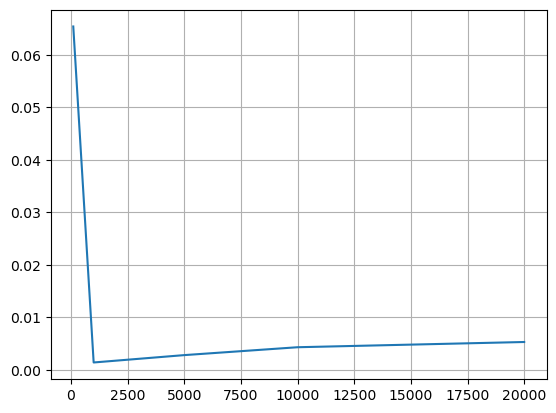

In [3]:
N_times = [100, 1000, 5000, 10000, 20000]

samp = []
err = []
for N in N_times:
    
    cnt = 0
    # random numbers between 0 and 1
    for i in range(N):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)
        r2 = x**2 + y**2
    
        # hits (inside quarter circle)    
        if r2 < 1:
            cnt += 1

    samp.append(cnt/N)
    err.append(abs(cnt/N - pi_over_4))

print(err)
plt.plot(N_times,err)
plt.grid(True)  

#### Integration

Find the integration of $f(x)$ using Monte Carlo method. 

$$f(x) = \exp \bigg(-\frac{x}{2}\bigg).$$
$$I = \int_0^1 \exp \bigg(-\frac{x}{2}\bigg) dx = -2 \exp \bigg(-\frac{x}{2}\bigg) \bigg|_0^1 = 2e^{-1/2} + 2e^{-0/2} \sim 0.7893986805.$$

Using Monte Carlo:

$$I = (1-0) \frac{1}{N} \sum_1^N f(x_i)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x values from 0 to 10
x = np.linspace(0, 1, 101)
f = np.exp(-x / 2)

# plot
plt.figure()
plt.plot(x, f, label=r'$e^{-x/2}$')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('f')
plt.title('Plot of $e^{-x/2}$')
plt.legend()
plt.show()

In [ ]:
N_times = [100, 1000, 5000, 10000, 20000]

samp = []
err = []

for N in N_times:
    
    fi = 0
    for i in range(N):
        x = random.uniform(0, 1)
        fi += np.exp(-x/2)

    val = (1-0)*fi/N
    samp.append(val)
    err.append(abs(val-0.7893986805))

# print(samp)
print(err)
plt.plot(N_times,err)
plt.grid(True)     

#### Importance samping

$$\int_0^1 \exp\bigg(-\frac{x}{2}\bigg) = \int_0^{3/4} \frac{\exp\big(-1+\sqrt{1-y}\big)}{\sqrt{1-y}} dy$$

Monte Carlo weighted samping:

$$I = \bigg(\frac{3}{4}-0\bigg) <g(y)> = \bigg(\frac{3}{4}-0\bigg) \frac{1}{N} \sum_1^N g(y_i),$$

where 

$$g(y) = \frac{\exp\big(-1+\sqrt{1-y}\big)}{\sqrt{1-y}}.$$

In [ ]:
# x values from 0 to 10
y = np.linspace(0, 3/4, 101)
g = np.exp(-1+np.sqrt(1-y))/np.sqrt(1-y)*0.75

# plot
plt.figure()
plt.plot(y, g, label=r'$\frac{e^{-1+\sqrt{1-y}}}{\sqrt{1-y}}$')
plt.grid(True)
plt.xlabel('y')
plt.ylabel('g')
plt.title('Plot of g(y)')
plt.legend()
plt.show()

In [ ]:
N_times = [100, 1000, 5000, 10000, 20000]

samp = []
err = []

for N in N_times:
    
    gi = 0
    for i in range(N):
        y = random.uniform(0, 0.75)
        gi += np.exp(-1+np.sqrt(1-y))/np.sqrt(1-y)

    val = (0.75-0)*gi/N
    samp.append(val)
    err.append(abs(val-0.7893986805))

print(samp)
print(err)
plt.plot(N_times,err)
plt.grid(True) 